<div style="padding: 35px; color:white; margin:10px 0; font-size:170%; text-align:center;
            border-radius:10px; overflow:hidden;
            background-image: url('https://images.pexels.com/photos/912050/pexels-photo-912050.jpeg?auto=compress&cs=tinysrgb&w=1200');
            background-size:cover; background-position:center;">
  <b style="color:#000000; background: rgba(255,255,255,0.7); padding:6px 12px; border-radius:6px;">
    ✈️ Airline Passenger Satisfaction – ML vs ANN Project 🚀
  </b>
</div>


# About Dataset

**Context**

This dataset contains an airline passenger satisfaction survey. What factors are highly correlated to a satisfied (or dissatisfied) passenger? Can you predict passenger satisfaction?

**Content**

- Gender: Gender of the passengers (Female, Male)

- Customer Type: The customer type (Loyal customer, disloyal customer)

- Age: The actual age of the passengers

- Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)
- Class: Travel class in the plane of the passengers (Business, Eco, Eco Plus)

- Flight distance: The flight distance of this journey

- Inflight wifi service: Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)

- Departure/Arrival time convenient: Satisfaction level of Departure/Arrival time convenient

- Ease of Online booking: Satisfaction level of online booking

- Gate location: Satisfaction level of Gate location

- Food and drink: Satisfaction level of Food and drink

- Online boarding: Satisfaction level of online boarding

- Seat comfort: Satisfaction level of Seat comfort
- Inflight entertainment: Satisfaction level of inflight entertainment

- On-board service: Satisfaction level of On-board service

- Leg room service: Satisfaction level of Leg room service

- Baggage handling: Satisfaction level of baggage handling

- Check-in service: Satisfaction level of Check-in service

- Inflight service: Satisfaction level of inflight service

- Cleanliness: Satisfaction level of Cleanliness

- Departure Delay in Minutes: Minutes delayed when departure

- Arrival Delay in Minutes: Minutes delayed when Arrival
- Satisfaction: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)

> Note that this data set was modified from this dataset by John D here. It has been cleaned up for the purposes of classification.

# **Imports**


In [ ]:
!pip install -q keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
!pip install -q tf2onnx
!pip install -q onnx
!pip install -q onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 11.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler , RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , recall_score , f1_score , precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping
from keras.models import load_model
import tf2onnx
import onnx
from onnxruntime import InferenceSession
import os

In [ ]:
pd.set_option('display.max_columns', None)

# **Load Data**

In [ ]:
import kagglehub

path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")

print("Path to dataset files:", path)

df_train = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))


100%|██████████| 2.71M/2.71M [00:00<00:00, 32.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1


We will download the dataset directly from Kaggle using `kagglehub`.  
The dataset contains airline passenger satisfaction data, split into **train** and **test** CSV files.

- **Train.csv** → Used for training the models.  
- **Test.csv** → Used for final evaluation of the models.  

We load both files into Pandas DataFrames and display the first few rows to get an overview.

In [ ]:
df_train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


# **Explor Data**

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

We start by exploring the dataset to understand its structure and contents:  
- **`df.info()`** → Shows column names, data types, and null values.  

In [ ]:
def more_info(data):
  n_unique=[]
  uniques=[]
  data_type=[]
  missing_values=[]
  columns=[]
  max_values=[]
  min_values=[]

  for col in data.columns:
    columns.append(col)
    n_unique.append(data[col].nunique())
    uniques.append(data[col].unique())
    data_type.append(data[col].dtype)
    missing_values.append(data[col].isnull().sum())
    if data[col].dtype!='object':
      max_values.append(data[col].max())
      min_values.append(data[col].min())
    else:
      max_values.append(np.nan)
      min_values.append(np.nan)
  more_info_df = pd.DataFrame({'column': columns,
                                'n_unique': n_unique,
                                'uniques': uniques,
                                'data_type': data_type,
                                'missing_values': missing_values,
                               'max_values':max_values,
                               'min_values':min_values})
  return more_info_df

- **Custom `more_info()` function** → Gives extra details such as:
  - Number of unique values per column.
  - Unique values list.
  - Data type.
  - Missing values count.
  - Minimum and maximum values for numerical columns.  

  This helps in identifying:
1. Which features are categorical vs numerical.
2. Presence of missing values.
3. Potential issues like constant columns or outliers.

In [ ]:
infos=more_info(df_train)
infos

,column,n_unique,uniques,data_type,missing_values,max_values,min_values
0,Unnamed: 0,103904,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",int64,0,103903.0,0.0
1,id,103904,"[70172, 5047, 110028, 24026, 119299, 111157, 8...",int64,0,129880.0,1.0
2,Gender,2,"[Male, Female]",object,0,NaN,NaN
3,Customer Type,2,"[Loyal Customer, disloyal Customer]",object,0,NaN,NaN
4,Age,75,"[13, 25, 26, 61, 47, 52, 41, 20, 24, 12, 53, 3...",int64,0,85.0,7.0
5,Type of Travel,2,"[Personal Travel, Business travel]",object,0,NaN,NaN
6,Class,3,"[Eco Plus, Business, Eco]",object,0,NaN,NaN
7,Flight Distance,3802,"[460, 235, 1142, 562, 214, 1180, 1276, 2035, 8...",int64,0,4983.0,31.0
8,Inflight wifi service,6,"[3, 2, 4, 1, 5, 0]",int64,0,5.0,0.0
9,Departure/Arrival time convenient,6,"[4, 2, 5, 3, 1, 0]",int64,0,5.0,0.0


From the info table:
- Several categorical columns like *Gender*, *Customer Type*, *Type of Travel*, and *Class*.  
- Numerical columns such as *Age*, *Flight Distance*, and delay times.
- A small amount of missing data in **Arrival Delay in Minutes**.
- No meaningless outliers detected from a quick look at the unique values.

We also confirm the target variable is **satisfaction**.

**There are no explicit outliers (in terms of meaning)**

In [ ]:
infos[infos['data_type']=='object']

,column,n_unique,uniques,data_type,missing_values,max_values,min_values
2,Gender,2,"[Male, Female]",object,0,NaN,NaN
3,Customer Type,2,"[Loyal Customer, disloyal Customer]",object,0,NaN,NaN
5,Type of Travel,2,"[Personal Travel, Business travel]",object,0,NaN,NaN
6,Class,3,"[Eco Plus, Business, Eco]",object,0,NaN,NaN
24,satisfaction,2,"[neutral or dissatisfied, satisfied]",object,0,NaN,NaN


# **Cleaning**

## remove unimportant features

In [ ]:
df_train.drop(['Unnamed: 0','id'],axis=1,inplace=True)

## 1. Remove Unnecessary Columns
- Columns **`Unnamed: 0`** and **`id`** are just identifiers and do not provide predictive information.
- Removing them avoids adding noise to the models.

## Missing in Arrival Delay in Minutes

In [ ]:
px.histogram(df_train, x='Arrival Delay in Minutes',marginal = 'box')

## 1. Remove Unnecessary Columns
- Columns **`Unnamed: 0`** and **`id`** are just identifiers and do not provide predictive information.
- Removing them avoids adding noise to the models.

In [ ]:
df_train['Arrival Delay in Minutes'].median()

0.0

In [ ]:
df_train.fillna(df_train['Arrival Delay in Minutes'].median(), inplace=True)

- Since it's a numerical feature, we fill missing values with the **median** instead of the mean:
  - Median is robust to skewed distributions and outliers.
  - This prevents the feature from being biased by extreme values.

In [ ]:
infos=more_info(df_train)
infos[infos['column']=='Arrival Delay in Minutes']

,column,n_unique,uniques,data_type,missing_values,max_values,min_values
21,Arrival Delay in Minutes,455,"[18.0, 6.0, 0.0, 9.0, 23.0, 8.0, 35.0, 51.0, 1...",float64,0,1584.0,0.0


- Since it's a numerical feature, we fill missing values with the **median** instead of the mean:
  - Median is robust to skewed distributions and outliers.
  - This prevents the feature from being biased by extreme values.

## skwed data

In [ ]:
fig = make_subplots(rows=2, cols=2)

fig.add_trace(go.Histogram(x=df_train['Age']), row=1, col=1)
fig.add_trace(go.Histogram(x=df_train['Flight Distance']), row=1, col=2)
fig.add_trace(go.Histogram(x=df_train['Departure Delay in Minutes']), row=2, col=1)
fig.add_trace(go.Histogram(x=df_train['Arrival Delay in Minutes']), row=2, col=2)

fig.update_layout(height=800, width=1200,title_text="Histogram of Numerical Features")
fig.update_xaxes(title_text="Age", row=1, col=1)
fig.update_xaxes(title_text="Flight Distance", row=1, col=2)
fig.update_xaxes(title_text="Departure Delay in Minutes", row=2, col=1)
fig.update_xaxes(title_text="Arrival Delay in Minutes", row=2, col=2)
fig.show()

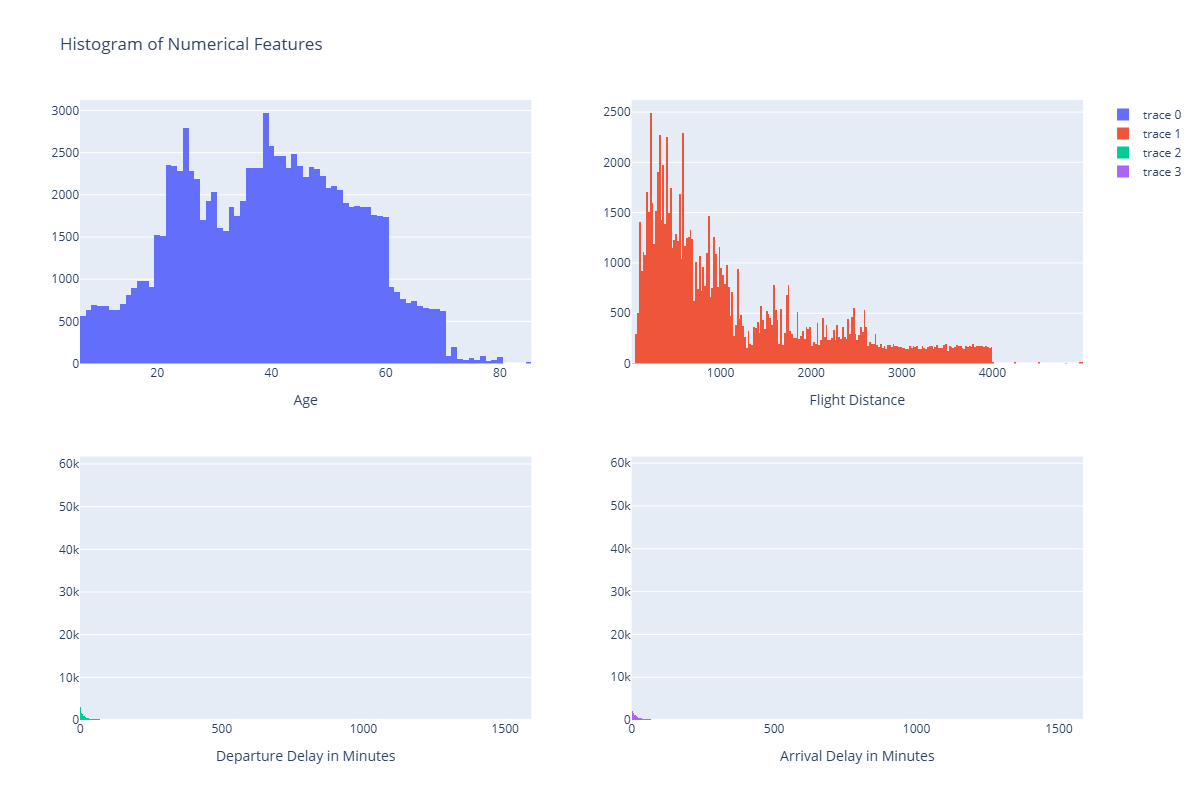

🔼 **If it doesn't support visualizing it from px**

Many numerical features have **skewed distributions**, which can negatively affect model performance, especially for algorithms sensitive to feature scaling.

We visualize histograms for:
- Age
- Flight Distance
- Departure Delay in Minutes
- Arrival Delay in Minutes


In [ ]:
df_train['Flight Distance']=np.log1p(df_train['Flight Distance'])
df_train['Departure Delay in Minutes']=np.log1p(df_train['Departure Delay in Minutes'])
df_train['Arrival Delay in Minutes']=np.log1p(df_train['Arrival Delay in Minutes'])
df_test['Flight Distance']=np.log1p(df_test['Flight Distance'])
df_test['Departure Delay in Minutes']=np.log1p(df_test['Departure Delay in Minutes'])
df_test['Arrival Delay in Minutes']=np.log1p(df_test['Arrival Delay in Minutes'])

**Why fix skewness?**
- Skewed features can make models biased towards majority ranges.
- Applying transformations like **log1p** helps compress large values and make the distribution more symmetric.

**Steps applied:**
- For both train and test datasets, we apply:
  ```python
  np.log1p()

In [ ]:
fig = make_subplots(rows=2, cols=2)

fig.add_trace(go.Histogram(x=df_train['Age']), row=1, col=1)
fig.add_trace(go.Histogram(x=df_train['Flight Distance']), row=1, col=2)
fig.add_trace(go.Histogram(x=df_train['Departure Delay in Minutes']), row=2, col=1)
fig.add_trace(go.Histogram(x=df_train['Arrival Delay in Minutes']), row=2, col=2)

fig.update_layout(height=800, width=1200,title_text="Histogram of Numerical Features")
fig.update_xaxes(title_text="Age", row=1, col=1)
fig.update_xaxes(title_text="Flight Distance", row=1, col=2)
fig.update_xaxes(title_text="Departure Delay in Minutes", row=2, col=1)
fig.update_xaxes(title_text="Arrival Delay in Minutes", row=2, col=2)
fig.show()

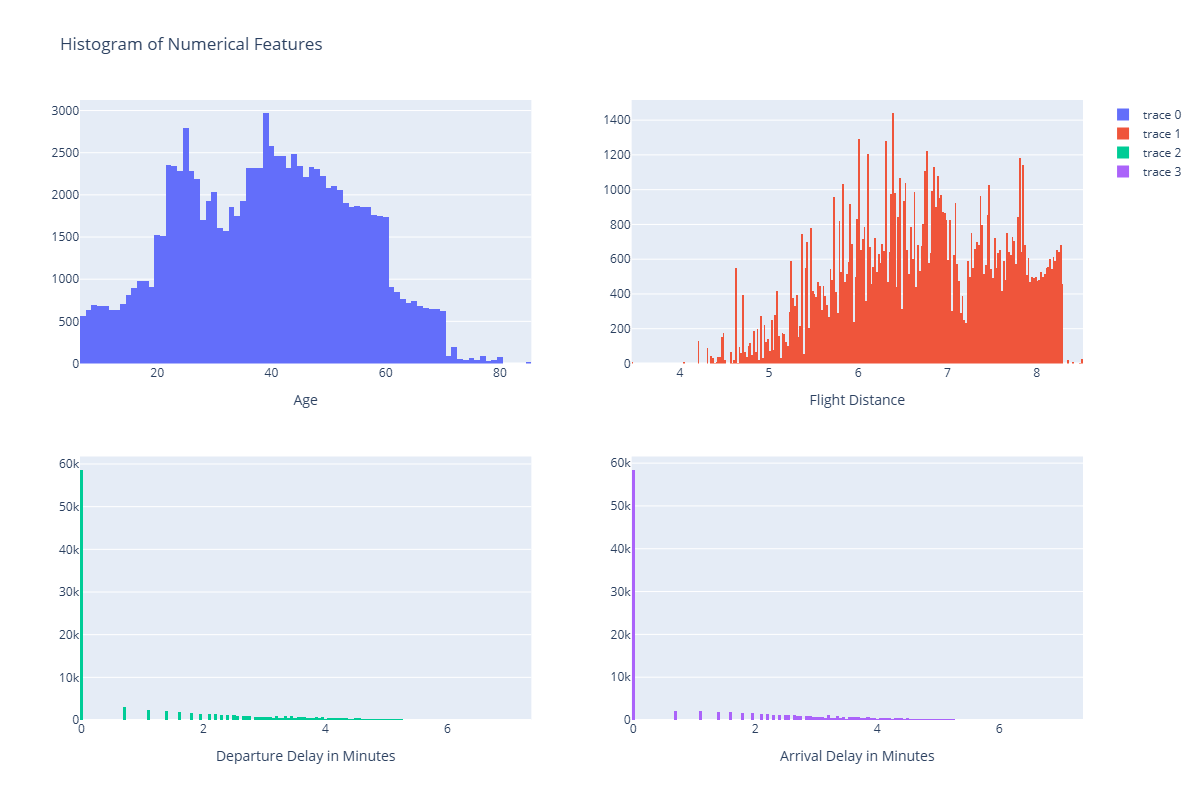

🔼 **If it doesn't support visualizing it from px**

After transformation, we plot histograms again to confirm the improvement in distribution shape.

## for test data

In [ ]:
infos_test=more_info(df_test)
infos_test

,column,n_unique,uniques,data_type,missing_values,max_values,min_values
0,Unnamed: 0,25976,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",int64,0,25975.000000,0.000000
1,id,25976,"[19556, 90035, 12360, 77959, 36875, 39177, 794...",int64,0,129877.000000,17.000000
2,Gender,2,"[Female, Male]",object,0,NaN,NaN
3,Customer Type,2,"[Loyal Customer, disloyal Customer]",object,0,NaN,NaN
4,Age,75,"[52, 36, 20, 44, 49, 16, 77, 43, 47, 46, 33, 6...",int64,0,85.000000,7.000000
5,Type of Travel,2,"[Business travel, Personal Travel]",object,0,NaN,NaN
6,Class,3,"[Eco, Business, Eco Plus]",object,0,NaN,NaN
7,Flight Distance,3281,"[5.081404364984463, 7.9599745280805365, 5.2626...",float64,0,8.513988,3.465736
8,Inflight wifi service,6,"[5, 1, 2, 0, 3, 4]",int64,0,5.000000,0.000000
9,Departure/Arrival time convenient,6,"[4, 1, 0, 3, 5, 2]",int64,0,5.000000,0.000000


In [ ]:
df_test.drop(['Unnamed: 0','id'],axis=1,inplace=True)
df_test.fillna(df_train['Arrival Delay in Minutes'].median(), inplace=True)

Again, do the same thing in the test data.

#

# Encoding

Machine learning models (except tree-based ones) require **numerical inputs**.  
Since our dataset contains categorical columns, we need to encode them into numbers.

## Chosen Method: **Manual Mapping**
- We use a **dictionary mapping** for each column.
- This is **label encoding** but with predefined values to ensure logical ordering.
- For example:
  - **Gender**: Male → 0, Female → 1
  - **Customer Type**: disloyal → 0, loyal → 1
  - **Type of Travel**: Personal → 0, Business → 1
  - **Class**: Eco → 0, Eco Plus → 1, Business → 2
  - **Satisfaction**: neutral/dissatisfied → 0, satisfied → 1


In [ ]:
encoding_map={
    'Gender':{'Male':0,'Female':1},
    'Customer Type':{'disloyal Customer':0,'Loyal Customer':1},
    'Type of Travel':{'Personal Travel':0,'Business travel':1},
    'Class':{'Eco':0,'Eco Plus':1,'Business':2},
    'satisfaction':{'neutral or dissatisfied':0,'satisfied':1}
}

for col, mapping in encoding_map.items():
  df_train[col] = df_train[col].map(mapping)

df_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,1,13,0,1,6.133398,3,4,3,1,5,3,5,5,4,3,4,4,5,5,3.258097,2.944439,0
1,0,0,25,1,2,5.463832,3,2,3,3,1,3,1,1,1,5,3,1,4,1,0.693147,1.945910,0
2,1,1,26,1,2,7.041412,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0.000000,0.000000,1
3,1,1,25,1,2,6.333280,2,5,5,5,2,2,2,2,2,5,3,1,4,2,2.484907,2.302585,0
4,0,1,61,1,2,5.370638,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0.000000,0.000000,1



## Why manual mapping?
- It’s **transparent** (you control the mapping).
- It ensures **consistency** between train and test datasets.
- It’s **faster** than `LabelEncoder` for a known, fixed set of categories.

In [ ]:
for col, mapping in encoding_map.items():
  df_test[col] = df_test[col].map(mapping)

df_test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,52,1,0,5.081404,5,4,3,4,3,4,3,5,5,5,5,2,5,5,3.931826,3.806662,1
1,1,1,36,1,2,7.959975,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0.000000,0.000000,1
2,0,0,20,1,0,5.262690,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0.000000,0.000000,0
3,0,1,44,1,2,8.125039,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0.000000,1.945910,1
4,1,1,49,1,0,7.075809,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0.000000,3.044522,1


⚠️ **Important:**  
When encoding train and test data, we apply the **same mapping** to avoid data mismatch.

# split

In [ ]:
x_train=df_train.drop('satisfaction',axis=1)
y_train=df_train['satisfaction']
x_test=df_test.drop('satisfaction',axis=1)
y_test=df_test['satisfaction']

Before training, we separate:
- **Features (X)** → All columns except the target.
- **Target (y)** → The `satisfaction` column (0 = dissatisfied, 1 = satisfied).

This separation is crucial so that models **only learn from features**,  
and evaluation is done against unseen `y` values.


# scaling

- Many ML algorithms (e.g., Logistic Regression, Neural Networks) are **sensitive to feature magnitude**.
- Features with large ranges may dominate the learning process if not scaled.

In [ ]:
# scaler=StandardScaler()
# x_train=scaler.fit_transform(x_train)
# x_test=scaler.transform(x_test)

In [ ]:
R_scaler=RobustScaler()
x_train=R_scaler.fit_transform(x_train)
x_test=R_scaler.transform(x_test)

- **Why RobustScaler?**
  - Unlike `StandardScaler`, it is **less sensitive to outliers**.
  - Uses **median** and **IQR (Interquartile Range)** for scaling instead of mean and standard deviation.

- This is ideal since our dataset has **some skewed features** even after transformation.

✅ Scaling is fitted **only on training data** to avoid data leakage,  
then applied to both train and test sets.

# Traditional ML

## LogisticRegression

## Why Logistic Regression?
- Simple yet powerful **linear model** for binary classification.
- Produces probabilities using the **sigmoid function**.
- Works well as a baseline model to compare with more complex models.



In [ ]:
log_model=LogisticRegression()
param_distributions = [
    {'solver': ['saga'], 'penalty': [None], 'max_iter': [100, 200]},
    {'solver': ['saga'], 'penalty': ['elasticnet'], 'l1_ratio': [0.1, 0.5, 0.9], 'C': [0.01, 0.1, 1, 10], 'max_iter': [100, 200]},
    {'solver': ['saga'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10], 'max_iter': [100, 200]}
]


grid_log = RandomizedSearchCV(
    estimator=log_model,
    param_distributions=param_distributions,
    scoring='accuracy',
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=3
)

grid_log.fit(x_train, y_train)

print("Best train Parameters :", grid_log.best_params_)
print("Best train Score:", grid_log.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best train Parameters : {'solver': 'saga', 'penalty': 'elasticnet', 'max_iter': 100, 'l1_ratio': 0.5, 'C': 0.1}
Best train Score: 0.8754812544163875


## **Hyperparameter Tuning**
We used **RandomizedSearchCV** to find the best combination of hyperparameters:
- **Why RandomizedSearchCV?**
  - Faster than GridSearchCV for large parameter spaces.
  - Samples a fixed number of combinations from the full parameter grid.

---

### **Tuned Parameters**
1. **solver** → Optimization algorithm (`saga` supports l1, l2, and elasticnet penalties).
2. **penalty** → Regularization type:
   - `l1` → Lasso (sparse features)
   - `l2` → Ridge (weight shrinkage)
   - `elasticnet` → Combination of L1 and L2
   - `None` → No regularization
3. **C** → Inverse of regularization strength (smaller C → stronger regularization).
4. **l1_ratio** → ElasticNet balance between L1 and L2 penalties.
5. **max_iter** → Max number of iterations to converge.



In [ ]:
final_log=LogisticRegression(C=0.1,max_iter=100,penalty='elasticnet',solver='saga',l1_ratio=0.5)
final_log.fit(x_train,y_train)
y_pred=final_log.predict(x_test)
print(classification_report(y_test,y_pred))
test_log=accuracy_score(y_test,y_pred)
recall_log=recall_score(y_test,y_pred)
f1score_log=f1_score(y_test,y_pred)
precision_log=precision_score(y_test,y_pred)
print('test accuracy: ',test_log)
print('test recall: ',recall_log)
print('test f1score: ',f1score_log)
print('test precision: ',precision_log)

              precision    recall  f1-score   support

           0       0.87      0.90      0.89     14573
           1       0.87      0.83      0.85     11403

    accuracy                           0.87     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.87      0.87      0.87     25976

test accuracy:  0.8724206960271019
test recall:  0.8341664474261159
test f1score:  0.8516429402811353
test precision:  0.86986739826246




## **Evaluation Metrics**
We computed:
- **Accuracy** → Overall correctness.
- **Recall** → How many actual positives were correctly identified.
- **F1-score** → Balance between precision and recall.
- **Precision** → How many predicted positives are correct.

These metrics give a **more complete view** than accuracy alone,  
especially for datasets with possible class imbalance.

## RandomForestClassifier

## Why Random Forest?
- **Ensemble method** that builds multiple decision trees and averages their results.
- Reduces overfitting compared to a single decision tree.
- Can model **non-linear relationships** and handle mixed feature types.
- Provides **feature importance** scores.

---

# **Hyperparameter Tuning**
We used **RandomizedSearchCV** again for efficiency.





In [ ]:
rf_model = RandomForestClassifier()
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    scoring='accuracy',
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=3
)

grid_rf.fit(x_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   scoring='accuracy', verbose=3)

## **Tuned Parameters**
1. **n_estimators** → Number of trees in the forest.
   - More trees → more stable predictions, but higher computational cost.
2. **max_depth** → Maximum depth of trees.
   - Controls model complexity; too deep → overfitting.
3. **min_samples_split** → Minimum samples required to split a node.
   - Higher values → less complex trees.
4. **min_samples_leaf** → Minimum samples at a leaf node.
   - Helps smooth the model by preventing overly small leaves.

In [ ]:
print("Best train Parameters :", grid_rf.best_params_)
print("Best train Score:", grid_rf.best_score_)

Best train Parameters : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Best train Score: 0.9624364976910547



## **Advantages over Logistic Regression**
- Can **capture non-linear patterns**.
- Handles **outliers and skewed features** better without needing heavy preprocessing.
- Does not require scaling of features.


In [ ]:
final_rf=RandomForestClassifier(n_estimators=200,min_samples_split=5,min_samples_leaf=1,max_depth=None)
final_rf.fit(x_train,y_train)
y_pred=final_rf.predict(x_test)
print(classification_report(y_test,y_pred))
test_rf=accuracy_score(y_test,y_pred)
recall_rf=recall_score(y_test,y_pred)
f1score_rf=f1_score(y_test,y_pred)
precision_rf=precision_score(y_test,y_pred)
print('test accuracy: ',test_rf)
print('test recall: ',recall_rf)
print('test f1score: ',f1score_rf)
print('test precision: ',precision_rf)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976

test accuracy:  0.9629273175238682
test recall:  0.9427343681487328
test f1score:  0.9571295018474826
test precision:  0.9719710669077758




## **Evaluation Metrics**
Same as before:
- **Accuracy**
- **Recall**
- **F1-score**
- **Precision**

This allows a **direct comparison** between Random Forest, Logistic Regression, and ANN.

# **Artificial Neural Network (ANN)**
## Why ANN?
- Can **model complex, non-linear relationships** between features and target.
- Learns feature interactions automatically without manual engineering.
- Good choice when dataset is **large** and has many features.



In [ ]:
NN_model=Sequential([
    Dense(256,activation='relu',input_shape=(x_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16,activation='relu'),
    BatchNormalization(),
    Dense(1,activation='sigmoid')
])

NN_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
early=EarlyStopping(monitor='val_accuracy',patience=7,restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



## **Network Architecture**
1. **Input Layer** → matches the number of features after preprocessing.
2. **Hidden Layers**:
   - Dense layers with `ReLU` activation → capture non-linearities.
   - **BatchNormalization** after each Dense:
     - Normalizes activations between layers.
     - Helps with faster and more stable training.
   - **Dropout** after each BatchNormalization:
     - Randomly drops a fraction of neurons.
     - Reduces overfitting and improves generalization.
3. **Output Layer**:
   - Single neuron with `sigmoid` activation → outputs probability for binary classification.

---

# **Why EarlyStopping?**
- Monitors `val_accuracy`.
- Stops training when performance stops improving for a set patience period.
- Saves computation time and prevents overfitting.


In [ ]:
history=NN_model.fit(x_train,y_train,validation_split=0.2,epochs=100,batch_size=128,callbacks=[early])

Epoch 1/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8591 - loss: 0.3211 - val_accuracy: 0.9425 - val_loss: 0.1392
Epoch 2/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9295 - loss: 0.1721 - val_accuracy: 0.9529 - val_loss: 0.1141
Epoch 3/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9420 - loss: 0.1423 - val_accuracy: 0.9547 - val_loss: 0.1076
Epoch 4/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9463 - loss: 0.1283 - val_accuracy: 0.9587 - val_loss: 0.1008
Epoch 5/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9505 - loss: 0.1204 - val_accuracy: 0.9619 - val_loss: 0.0935
Epoch 6/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9535 - loss: 0.1135 - val_accuracy: 0.9601 - val_loss: 0.0933
Epoch 7/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9547 - loss: 0.1093 - val_accuracy: 0.9609 - val_loss: 0.0908
Epoch 8/100
650/650 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9572 - loss: 0.1048 - 

In [ ]:
loss,acc=NN_model.evaluate(x_test,y_test)
print(f'loss={loss},acc={acc}')

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9637 - loss: 0.0847
loss=0.08339206874370575,acc=0.9646211862564087


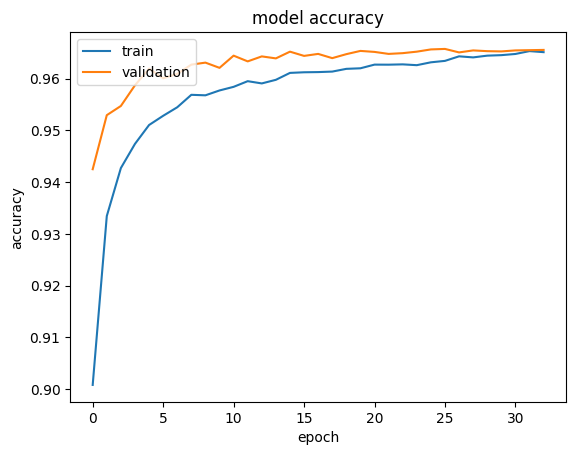

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
NN_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,965 (597.52 KB)

 Trainable params: 50,657 (197.88 KB)

 Non-trainable params: 992 (3.88 KB)

 Optimizer params: 101,316 (395.77 KB)

In [ ]:
import keras_tuner as kt
from keras_tuner.engine.hyperparameters import Int

def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int('units_1', min_value=64, max_value=512, step=64),
        activation='relu',
        input_shape=(x_train.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)))

    model.add(Dense(
        units=hp.Int('units_2', min_value=32, max_value=256, step=32),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1)))
    model.add(Dense(
        units=hp.Int('units_3', min_value=16, max_value=128, step=16),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_3', 0.1, 0.5, step=0.1)))
    model.add(Dense(
        units=hp.Int('units_4', min_value=8, max_value=64, step=8),
        activation='relu'
    ))
    model.add(BatchNormalization())

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_dir',
    project_name='nn_tuning'
)

early_2 = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    filepath='best_tuned_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

tuner.search(
    x_train, y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=128,
    callbacks=[early_2,checkpoint],
    shuffle=True
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Trial 10 Complete [00h 07m 49s]
val_accuracy: 0.9656898379325867

Best val_accuracy So Far: 0.9672296643257141
Total elapsed time: 00h 56m 36s



## **Hyperparameter Tuning with Keras Tuner**
We tuned:
1. **units per layer** → number of neurons in each Dense layer.
2. **dropout rates** → fraction of neurons dropped.
3. **batch size** → number of samples per training step.
4. **patience in EarlyStopping** → indirectly tested by longer training runs.

**RandomSearch** is used instead of Grid Search:
- Faster on high-dimensional hyperparameter space.
- Good trade-off between search completeness and time.

---

# **ModelCheckpoint**
- Saves only the **best model** based on `val_accuracy`.
- Allows loading the best-performing network after tuning without retraining.

---

# **Advantages over Traditional ML Models**
- Can learn more complex patterns.
- Scales well with dataset size.
- Flexible architecture allows fine-tuning for performance.



In [ ]:
best_model = load_model('/content/best_tuned_model.keras')

test_loss, test_acc = best_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

812/812 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9629 - loss: 0.0853
Test Accuracy: 0.9640


In this project, two approaches were tested to build the MLP (Multi-Layer Perceptron):

1. **Manual Architecture**  
   - Layers and neurons are chosen based on prior knowledge and intuition.  
   - Example: `[256 → 128 → 64 → 32 → 16]` with Batch Normalization & Dropout.  
   - **Test Accuracy:** `0.9646`

2. **Keras Tuner (Automated Hyperparameter Search)**  
   - Keras Tuner explores different combinations of:
     - Number of units per layer  
     - Dropout rates  
     - Number of layers  
   - **Test Accuracy:** `0.9640`


- **Performance is almost identical** in this case.
- Manual design was already close to optimal for this dataset.
- Keras Tuner randomly samples configurations from the defined search space, **not all combinations**.
- Limited trials (`max_trials`) help save time but reduce the chance of finding the absolute best configuration.



- Use **Manual MLP** when you have a good understanding of your problem and dataset.
- Use **Keras Tuner** when:
  - You have less intuition for the architecture.
  - The dataset is complex and requires testing many configurations.
  - You can afford longer training time for broader search.


In [ ]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,109 (324.65 KB)

 Trainable params: 27,425 (107.13 KB)

 Non-trainable params: 832 (3.25 KB)

 Optimizer params: 54,852 (214.27 KB)

In [ ]:
y_pred_NN=best_model.predict(x_test)
y_pred_NN=(y_pred_NN>0.5)
recall=recall_score(y_test,y_pred_NN)
f1score=f1_score(y_test,y_pred_NN)
precision=precision_score(y_test,y_pred_NN)
print(recall)
print(f1score)
print(precision)
print(classification_report(y_test,y_pred_NN))

812/812 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
0.9445759887748838
0.9583592846338642
0.97255079006772
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976




## **Evaluation**
- Used **accuracy**, **recall**, **F1-score**, and **precision** to compare with Logistic Regression and Random Forest.
- Produced a **comparative bar chart** to visualize differences between models.

# save as onnx & onnx runtime

In [ ]:
spec=[tf.TensorSpec([None,x_train.shape[1]],tf.float32,name='input')]

@tf.function(input_signature=spec)
def call(input):
    return NN_model(input)

In [ ]:
tf2onnx.convert.from_function(call,input_signature=spec,output_path='ANN_Airline_model.onnx')

In [ ]:
sess=InferenceSession('ANN_Airline_model.onnx',providers=['CPUExecutionProvider'])

input_name=sess.get_inputs()[0].name
output_name=sess.get_outputs()[0].name

prob=sess.run([output_name],{input_name:x_test.astype(np.float32)})[0]

# comperson

## **Model Comparison**
We compared three models:

  | Model | Accuracy | Recall | F1-score | Precision |
  |-------|----------|--------|----------|-----------|
  | Logistic Regression | 0.8724 | 0.8342 | 0.8516 | 0.8699 |
  | Random Forest | 0.9629 | 0.9427 | 0.9571 | 0.9720 |
  | ANN (Tuned) | **0.9641** | **0.9422** | **0.9584** | **0.9752** |

---




In [ ]:
model_names = ['LogisticRegression', 'RandomForestClassifier', 'ANN']

metric_names = ['Accuracy', 'Recall', 'F1-score', 'Precision']

metric_values = [
    [test_log, recall_log, f1score_log, precision_log],
    [test_rf, recall_rf, f1score_rf, precision_rf],
    [test_acc, recall, f1score, precision]
]

data = []
for i, model in enumerate(model_names):
    for j, metric in enumerate(metric_names):
        data.append({'Model': model, 'Metric': metric, 'Value': metric_values[i][j]})

df_metrics = pd.DataFrame(data)

fig = px.bar(df_metrics, x='Metric', y='Value', color='Model', barmode='group',
             labels={'Model': 'Model', 'Value': 'Score'},
             title='Comparison of Model Performance Metrics')

fig.show()

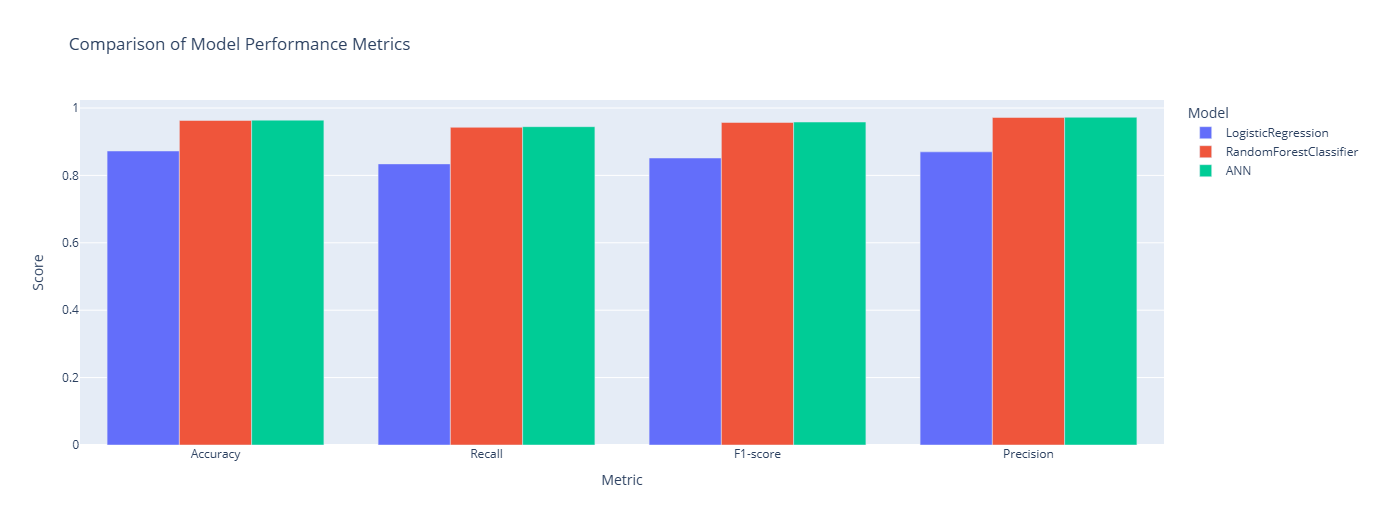

🔼 **If it doesn't support visualizing it from px**

In [ ]:
import plotly.graph_objects as go

model_names = ['LogisticRegression', 'RandomForestClassifier', 'ANN']

metric_names = ['Accuracy', 'Recall', 'F1-score', 'Precision']

metric_values = [
    [test_log, recall_log, f1score_log, precision_log],
    [test_rf, recall_rf, f1score_rf, precision_rf],
    [test_acc, recall, f1score, precision]
]

fig_radar = go.Figure()

for i, model in enumerate(model_names):
    fig_radar.add_trace(go.Scatterpolar(
        r=metric_values[i],
        theta=metric_names,
        fill='toself',
        name=model
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0.8, 1.0])
    ),
    title="Radar Chart - Model Performance Comparison",
    showlegend=True
)

fig_radar.show()

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


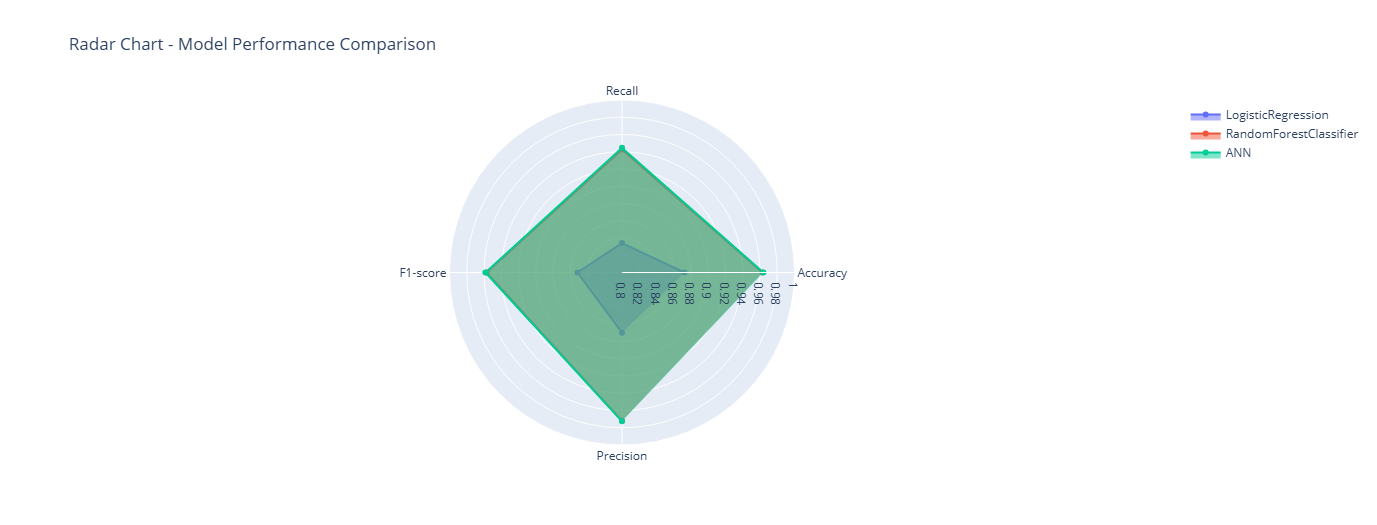

🔼 **If it doesn't support visualizing it from go**

## **Insights**
- **Logistic Regression**:  
  - Performs reasonably well but struggles with complex non-linear relationships in the data.
  - Lower recall means it misses more positive cases compared to other models.

- **Random Forest**:  
  - Significant performance improvement over Logistic Regression.
  - Strong ability to handle feature interactions and non-linearities.
  - High precision and recall balance.

- **ANN (Artificial Neural Network)**:  
  - Achieved the **highest accuracy (96.54%)** and best overall balance between precision and recall.
  - Benefit from hyperparameter tuning and regularization techniques.
  - Performs slightly better than Random Forest on all metrics.



### Why ANN is Close to Random Forest in Performance?

Even though Artificial Neural Networks (ANN) are often considered more advanced than traditional models, in this case the **ANN (Tuned)** is only slightly better than **Random Forest** for a few reasons:

1. **Data Size & Complexity**  
   - The dataset is not extremely large or complex.  
   - Random Forests handle small-to-medium datasets with structured tabular data very well, sometimes matching deep learning models.

2. **Nature of Features**  
   - Most features here are categorical or low-dimensional numerical values.  
   - Tree-based models like Random Forest excel in handling such features without heavy preprocessing.  
   - ANN may need more feature interactions or large-scale patterns to significantly outperform.

3. **Tuning & Overfitting Control**  
   - Both models were tuned with good hyperparameters.  
   - ANN benefits from Batch Normalization & Dropout, while RF benefits from its ensemble nature, making both strong and robust.

4. **Non-linear Relationships**  
   - The dataset likely contains relationships that both ANN and RF can capture effectively.  
   - This reduces the performance gap between the two.

**Conclusion:**  
On structured tabular datasets, well-tuned Random Forest models can be as competitive as deep learning models. ANN’s strength becomes more pronounced when data is **very large**, **high-dimensional**, or **unstructured** (like images, audio, or text)

# **Conclusion**
- While Random Forest already provides strong performance, ANN shows a marginal improvement in all metrics.
- This improvement, although small, can be critical in production scenarios where accuracy and recall directly impact business value.
- ANN is recommended for deployment if computational resources are sufficient.